In [ ]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import pandas as pd

from server.sre_environment import SREEnvironment, SREAction

action_delay = 3
action_queue = deque([0]*action_delay, maxlen=action_delay)

env = SREEnvironment()
obs = env.reset()

SERVICES = sorted(list(obs.metrics.keys()))

def is_leaf(obs, svc):
    return len(obs.dependency_graph[svc]) == 0

def encode_state(obs):
    vec = []
    for svc in SERVICES:
        m = obs.metrics[svc]

        lat = max(0, m["latency_p99"])
        err = m["error_rate"]
        mem = m.get("memory_pct", 0)

        vec.extend([
            lat / 500.0,
            err,
            mem / 100.0,
            1.0 if is_leaf(obs, svc) else 0.0
        ])

    return np.array(vec, dtype=np.float32)

In [2]:
ACTION_TYPES = ["restart", "scale_up", "rollback", "circuit_break"]

ACTION_MAP = []
for a in ACTION_TYPES:
    for s in SERVICES:
        ACTION_MAP.append((a, s))

ACTION_MAP.append(("wait", None))

NUM_ACTIONS = len(ACTION_MAP)

In [3]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, size=50000):
        self.buffer = deque(maxlen=size)

    def add(self, *transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = zip(*batch)

        return (
            torch.tensor(np.array(s), dtype=torch.float32),
            torch.tensor(a),
            torch.tensor(r, dtype=torch.float32),
            torch.tensor(np.array(s2), dtype=torch.float32),
            torch.tensor(d, dtype=torch.float32)
        )

    def __len__(self):
        return len(self.buffer)

In [20]:
def add_noise(state, noise_level=0.05):
    noise = np.random.normal(0, noise_level, size=state.shape)
    return state + noise

In [54]:
def train_dqn(tier='easy', episodes=20000):
    env = SREEnvironment()
    
    state_dim = len(encode_state(env.reset()))

    q_net = DQN(state_dim, NUM_ACTIONS)
    target_net = DQN(state_dim, NUM_ACTIONS)
    target_net.load_state_dict(q_net.state_dict())

    optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
    buffer = ReplayBuffer()

    gamma = 0.95
    epsilon = 1.0

    rewards = []

    def select_action(state, epsilon):
        if random.random() < epsilon:
            return random.randint(0, NUM_ACTIONS - 1)
        with torch.no_grad():
            q = q_net(torch.tensor(state).unsqueeze(0))
            return int(torch.argmax(q))

    for ep in range(episodes):
        obs = env.reset(task_tier=tier)
        state = encode_state(obs)

        total_reward = 0

        while not obs.done:
            action_idx = select_action(state, epsilon)
            action_type, service = ACTION_MAP[action_idx]

            action = SREAction(action=action_type, service_id=service)
            next_obs = env.step(action)
            next_state = encode_state(next_obs)

            reward = next_obs.reward

            # prevent lazy policy
            if not all(next_obs.sla_status.values()):
                reward -= 0.1

            buffer.add(state, action_idx, reward, next_state, next_obs.done)

            # train
            if len(buffer) > 64:
                states, actions, rewards_b, next_states, dones = buffer.sample(64)

                q_values = q_net(states)
                next_q = target_net(next_states).max(dim=1)[0]

                target = rewards_b + gamma * next_q * (1 - dones)
                current_q = q_values.gather(1, actions.unsqueeze(1)).squeeze()

                loss = nn.MSELoss()(current_q, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            state = next_state
            obs = next_obs
            total_reward += reward

        rewards.append(total_reward)

        epsilon = max(0.05, epsilon * 0.995)

        if ep % 200 == 0:
            target_net.load_state_dict(q_net.state_dict())

        if ep % 10 == 0:
            print(f"[{tier}] Episode {ep}, avg reward: {np.mean(rewards[-100:]):.2f}")

    return q_net, rewards

In [55]:
print("Training EASY...")
easy_model, rew_easy = train_dqn("easy", episodes=1000)

print("\nTraining MEDIUM...")
medium_model, rew_med = train_dqn("medium", episodes=1000)

print("\nTraining HARD...")
hard_model, rew_hard = train_dqn("hard", episodes=1000)

Training EASY...
[easy] Episode 0, avg reward: 13.40
[easy] Episode 10, avg reward: 19.36
[easy] Episode 20, avg reward: 20.85
[easy] Episode 30, avg reward: 20.38
[easy] Episode 40, avg reward: 20.41
[easy] Episode 50, avg reward: 20.35
[easy] Episode 60, avg reward: 20.52
[easy] Episode 70, avg reward: 20.11
[easy] Episode 80, avg reward: 20.20
[easy] Episode 90, avg reward: 20.25
[easy] Episode 100, avg reward: 20.27
[easy] Episode 110, avg reward: 20.43
[easy] Episode 120, avg reward: 20.23
[easy] Episode 130, avg reward: 20.35
[easy] Episode 140, avg reward: 20.35
[easy] Episode 150, avg reward: 20.30
[easy] Episode 160, avg reward: 20.41
[easy] Episode 170, avg reward: 21.03
[easy] Episode 180, avg reward: 21.30
[easy] Episode 190, avg reward: 21.42
[easy] Episode 200, avg reward: 21.50
[easy] Episode 210, avg reward: 21.79
[easy] Episode 220, avg reward: 22.08
[easy] Episode 230, avg reward: 22.33
[easy] Episode 240, avg reward: 22.84
[easy] Episode 250, avg reward: 23.30
[easy]

In [56]:
def dqn_policy(model):
    def policy(obs):
        state = encode_state(obs)
        with torch.no_grad():
            q = model(torch.tensor(state).unsqueeze(0))
            action_idx = int(torch.argmax(q))

        action_type, service = ACTION_MAP[action_idx]
        return SREAction(action=action_type, service_id=service)
    return policy


def random_policy(obs):
    a, s = random.choice(ACTION_MAP)
    return SREAction(action=a, service_id=s)


def smart_policy(obs):
    best = None
    best_score = -1

    for svc, m in obs.metrics.items():
        score = m["error_rate"] * 2 + m.get("memory_pct", 0) / 100.0
        if score > best_score:
            best_score = score
            best = svc

    return SREAction(action="restart", service_id=best)

In [57]:
def run_eval(policy, tier, episodes=50):
    rewards = []

    for ep in range(episodes):
        env = SREEnvironment(seed=ep)
        obs = env.reset(task_tier=tier)

        total = 0

        while not obs.done:
            action = policy(obs)
            obs = env.step(action)
            total += obs.reward

        rewards.append(total)

    return np.mean(rewards), np.std(rewards)

In [58]:
results = []

agents = [
    ("Random", random_policy),
    ("Smart", smart_policy),
    ("DQN Easy", dqn_policy(easy_model)),
    ("DQN Medium", dqn_policy(medium_model)),
    ("DQN Hard", dqn_policy(hard_model)),
]

for name, policy in agents:
    for tier in ["easy", "medium", "hard"]:
        mean, std = run_eval(policy, tier)
        results.append({
            "Agent": name,
            "Tier": tier,
            "Mean Reward": mean,
            "Std": std
        })

df = pd.DataFrame(results)
print(df)

         Agent    Tier  Mean Reward           Std
0       Random    easy    20.420286  4.083942e+00
1       Random  medium    21.638857  3.129584e+00
2       Random    hard    22.247714  3.121405e+00
3        Smart    easy    32.000000  3.552714e-15
4        Smart  medium    15.308571  1.661659e+00
5        Smart    hard    22.520000  3.348318e+00
6     DQN Easy    easy    33.350000  1.220656e-01
7     DQN Easy  medium     8.526857  1.825251e-01
8     DQN Easy    hard    29.951571  3.064544e+00
9   DQN Medium    easy    28.899000  5.186610e+00
10  DQN Medium  medium    32.785714  3.416526e-01
11  DQN Medium    hard    28.916286  4.537749e+00
12    DQN Hard    easy    23.161286  3.470056e+00
13    DQN Hard  medium    17.334143  1.318453e+01
14    DQN Hard    hard    33.218714  3.070694e-01


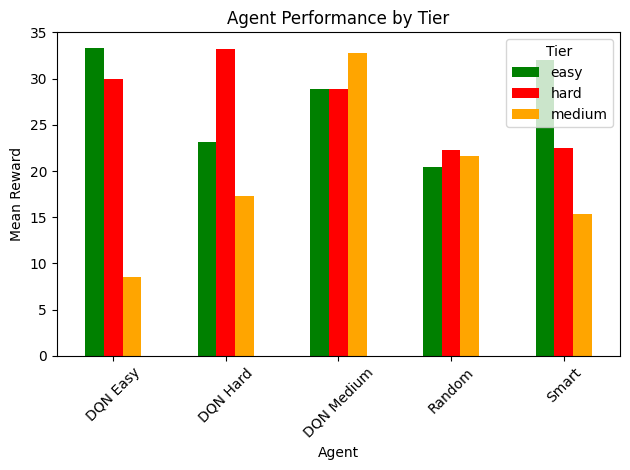

In [63]:
import matplotlib.pyplot as plt

pivot = df.pivot(index="Agent", columns="Tier", values="Mean Reward")

pivot.plot(
    kind="bar",
    color=["green", "red", "orange"]  # easy, medium, hard
)

plt.ylabel("Mean Reward")
plt.title("Agent Performance by Tier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

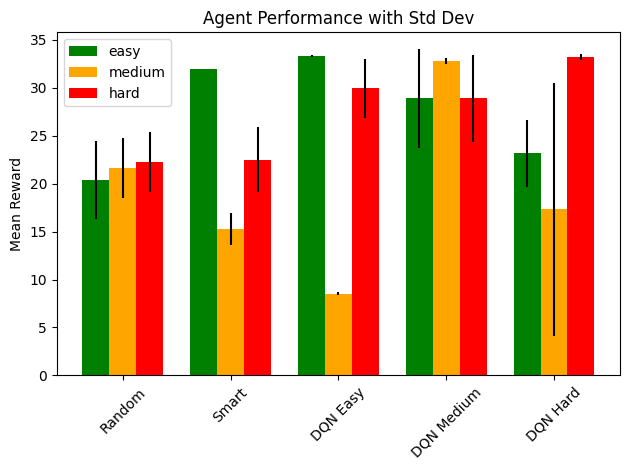

In [60]:
import numpy as np
import matplotlib.pyplot as plt

agents = df["Agent"].unique()
tiers = ["easy", "medium", "hard"]

# Define colors for each tier
colors = {
    "easy": "green",
    "medium": "orange",
    "hard": "red"
}

x = np.arange(len(agents))
width = 0.25

fig, ax = plt.subplots()

for i, tier in enumerate(tiers):
    subset = df[df["Tier"] == tier]
    means = subset["Mean Reward"].values
    stds = subset["Std"].values
    
    ax.bar(
        x + i*width,
        means,
        width,
        yerr=stds,
        label=tier,
        color=colors[tier]   
    )

ax.set_ylabel("Mean Reward")
ax.set_title("Agent Performance with Std Dev")
ax.set_xticks(x + width)
ax.set_xticklabels(agents, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

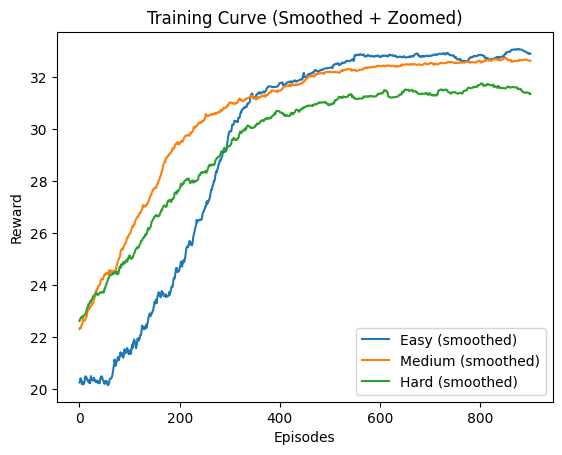

In [70]:
def moving_avg(x, w=100): return np.convolve(x, np.ones(w)/w, mode='valid')

plt.plot(moving_avg(rew_easy), label="Easy (smoothed)")
plt.plot(moving_avg(rew_med), label="Medium (smoothed)")
plt.plot(moving_avg(rew_hard), label="Hard (smoothed)")


plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Training Curve (Smoothed + Zoomed)")
plt.legend()
plt.show()